# Wasserstein Barycenter Grids

This notebook generates `fig:barycenters-four-shapes`.  The left panel uses the exact one-dimensional quantile formula for one Gaussian law and three asymmetric two-Gaussian mixtures.  The right panel computes entropic Wasserstein barycenters of four silhouettes on a common pixel grid using POT, with a small regularization so the intermediate boundaries remain sharp.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from PIL import Image
from scipy.ndimage import gaussian_filter, gaussian_filter1d
import ot

NAME = "barycenters-four-shapes"
out = figure_dir(NAME)
rng = np.random.default_rng(2027)
assets = FIGROOT / "assets"

## One-dimensional quantile barycenters

The four corner laws consist of one Gaussian and three different two-Gaussian mixtures, with distinct means, spreads and weights.  A barycenter with bilinear weights has quantile function equal to the same weighted average of the four corner quantile functions.


In [2]:
def gaussian(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)


def normalize_density(x, rho):
    dx = x[1] - x[0]
    return rho / (rho.sum() * dx)


def quantile_from_density(x, rho, r):
    dx = x[1] - x[0]
    F = np.cumsum(rho) * dx
    F = np.maximum.accumulate(F)
    F[-1] = 1.0
    return np.interp(r, F, x)


def weights(u, v):
    return np.array([(1 - u) * (1 - v), u * (1 - v), (1 - u) * v, u * v])

corner_colors = np.array([
    [0.839, 0.188, 0.153],
    [0.992, 0.682, 0.380],
    [0.482, 0.196, 0.580],
    [0.129, 0.400, 0.675],
])

def bilinear_color(u, v):
    return tuple(np.clip(weights(u, v) @ corner_colors, 0, 1))

xgrid = np.linspace(-4.2, 4.2, 3000)
r = np.linspace(1e-4, 1 - 1e-4, 900)
densities_1d = [
    gaussian(xgrid, -1.95, 0.34),
    0.72 * gaussian(xgrid, -1.55, 0.22) + 0.28 * gaussian(xgrid, 1.08, 0.46),
    0.38 * gaussian(xgrid, -2.30, 0.43) + 0.62 * gaussian(xgrid, 0.70, 0.20),
    0.56 * gaussian(xgrid, -0.72, 0.26) + 0.44 * gaussian(xgrid, 2.18, 0.33),
]
quantiles = np.vstack([quantile_from_density(xgrid, normalize_density(xgrid, d), r) for d in densities_1d])

uv = np.linspace(0, 1, 5)
fig, ax = plt.subplots(figsize=(3.10, 3.10))
for row, v in enumerate(uv[::-1]):
    for col, u in enumerate(uv):
        q = weights(float(u), float(v)) @ quantiles
        hist, edges = np.histogram(q, bins=96, range=(-3.35, 3.35), density=True)
        hist = gaussian_filter1d(hist, sigma=0.70)
        hist = hist / max(hist.max(), 1e-12)
        xs = 0.5 * (edges[:-1] + edges[1:])
        xs = col + 0.07 + 0.86 * (xs - xs.min()) / (xs.max() - xs.min())
        y0 = row + 0.10
        ys = y0 + 0.76 * hist
        color = bilinear_color(float(u), float(v))
        ax.fill_between(xs, y0, ys, color=color, alpha=0.26, linewidth=0)
        ax.plot(xs, ys, color=color, lw=0.88)
        ax.plot([col + 0.07, col + 0.93], [y0, y0], color=(0.78, 0.78, 0.78), lw=0.28, alpha=0.65)
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect("equal")
remove_axes(ax)
save_pdf(fig, out / "quantile-grid.pdf", pad_inches=0.030)
plt.close(fig)


## Entropic barycenters on a pixel grid

The four corner shapes are read from `notebooks-figures/assets`.  The grid remains modest, but the regularization is kept small (epsilon 4e-4) and each non-corner Sinkhorn solve is required to reach a 5e-8 residual.  The exported panel is rendered as a density image: values are clamped at their 95% quantile before colorization, with no threshold contour or boundary overlay.


In [3]:
def image_density(path, n=36):
    img = Image.open(path).convert("RGBA").resize((n, n), Image.Resampling.LANCZOS)
    arr = np.asarray(img)
    gray = np.asarray(img.convert("L"), dtype=float)
    alpha = arr[..., 3].astype(float)
    if alpha.max() - alpha.min() > 100 and alpha.min() < 80:
        mass = alpha
    else:
        mass = np.maximum(0.0, 242.0 - gray)
    mass = gaussian_filter(mass.astype(float), sigma=0.14)
    mass += 1e-8
    return mass / mass.sum()


def clamp_density(q, quantile=0.95):
    q = np.maximum(np.asarray(q, dtype=float), 0.0)
    level = np.quantile(q, quantile)
    level = max(float(level), 1e-12)
    return np.clip(q, 0.0, level) / level


shape_files = ["cat.png", "twodisks.png", "cross.jpg", "trefle.jpg"]
shape_densities = [image_density(assets / f, n=40) for f in shape_files]
A = np.column_stack([d.ravel() for d in shape_densities])
n_side = shape_densities[0].shape[0]
grid = np.linspace(0, 1, n_side)
X, Y = np.meshgrid(grid, grid)
coords = np.column_stack([X.ravel(), Y.ravel()])
M = ot.dist(coords, coords, metric="sqeuclidean")
M /= max(M.max(), 1e-12)

# Use a smaller epsilon than the previous draft and make convergence
# explicit: non-corner barycenters must reach the requested Sinkhorn residual.
barycenter_reg = 0.0004
barycenter_stop_thr = 5e-8
barycenter_num_iter = 50000
barys = []
convergence_log = []
for v in uv[::-1]:
    row = []
    for u in uv:
        w = weights(float(u), float(v))
        # Exact corner weights should display the actual input silhouettes and
        # need no entropic solve.
        if np.max(w) > 1 - 1e-12:
            q = shape_densities[int(np.argmax(w))].reshape(n_side, n_side)
            convergence_log.append((float(u), float(v), 0, 0.0))
        else:
            q, log = ot.bregman.barycenter(
                A,
                M,
                reg=barycenter_reg,
                weights=w,
                method="sinkhorn",
                numItermax=barycenter_num_iter,
                stopThr=barycenter_stop_thr,
                log=True,
                warn=False,
            )
            residuals = np.asarray(log.get("err", []), dtype=float)
            final_err = float(residuals[-1]) if residuals.size else np.inf
            niter = int(log.get("niter", barycenter_num_iter))
            if (not np.isfinite(final_err)) or final_err > 1.10 * barycenter_stop_thr:
                raise RuntimeError(
                    f"Sinkhorn barycenter did not converge at (u,v)=({u:.2f},{v:.2f}): "
                    f"residual={final_err:.3e}, iterations={niter}"
                )
            q = q.reshape(n_side, n_side)
            convergence_log.append((float(u), float(v), niter, final_err))
        q = clamp_density(gaussian_filter(q, sigma=0.035), quantile=0.95)
        row.append(q)
    barys.append(row)

active_log = [entry for entry in convergence_log if entry[2] > 0]
max_niter = max(entry[2] for entry in active_log)
max_residual = max(entry[3] for entry in active_log)
print(
    f"Entropic barycenter epsilon={barycenter_reg:g}; "
    f"max Sinkhorn iterations={max_niter}; max residual={max_residual:.2e}"
)

cell = n_side * 3
pad = 8
canvas = np.ones((5 * cell + 4 * pad, 5 * cell + 4 * pad, 3), dtype=float)
for row in range(5):
    for col in range(5):
        u = uv[col]
        v = uv[::-1][row]
        q = clamp_density(gaussian_filter(barys[row][col], sigma=0.060), quantile=0.95)
        color = np.array(bilinear_color(float(u), float(v)))
        alpha = np.clip(q ** 0.52, 0, 1)
        tile = (1 - alpha[..., None]) * np.ones((*q.shape, 3)) + alpha[..., None] * color
        tile_img = Image.fromarray(np.uint8(np.clip(tile, 0, 1) * 255)).resize((cell, cell), Image.Resampling.BICUBIC)
        tile = np.asarray(tile_img, dtype=float) / 255.0
        r0 = row * (cell + pad)
        c0 = col * (cell + pad)
        canvas[r0:r0 + cell, c0:c0 + cell] = tile

fig, ax = plt.subplots(figsize=(3.10, 3.10))
ax.imshow(canvas, interpolation="lanczos")
remove_axes(ax)
save_pdf(fig, out / "shape-grid.pdf", pad_inches=0.030)
plt.close(fig)


Entropic barycenter epsilon=0.0004; max Sinkhorn iterations=7171; max residual=5.00e-08


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


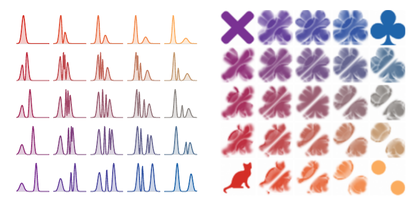

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/barycenters-four-shapes.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/barycenters-four-shapes.png")
display(Image(filename=str(_thumb)))
